# Data

In [4]:
import os
import functions
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

csvs = [file for file in os.listdir('./') if file.endswith('.csv')]
df_name = csvs[0]
df = pd.read_csv(f'./{df_name}')


numerical_columns = ['energy_consumption', 'temperature', 'humidity', 'wind_speed']
categorical_columns = None
binary_columns = None
datetime_column = 'timestamp'
target_column = 'energy_consumption'

df[target_column] = df[target_column]

df = functions.pre_process(df, numerical_columns, categorical_columns, binary_columns, datetime_column, target_column)

df = functions.get_datetime_features(df, datetime_column, cos_sin = False)

feature_names = ["Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend", "temperature", "humidity", "wind_speed", "energy_consumption"]
df = df[feature_names]

#scale type = both, features, outcome
X_train, y_train, X_val, y_val, X_test, y_test, X, y, df_scaled = functions.load_and_preprocess_data_with_sequences(df, target='energy_consumption', scaled=True, scale_type='features', val_ratio=0.1, test_ratio=0.1, input_seq_length=48, output_seq_length=24)

# Print shapes to verify
print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

df_scaled.head()


Shapes:
X_train: (20391, 48, 10)
y_train: (20391, 24, 1)
X_val: (2548, 48, 10)
y_val: (2548, 24, 1)
X_test: (2548, 48, 10)
y_test: (2548, 24, 1)


,Hour,DayOfWeek,DayOfMonth,Month,DayOfYear,IsWeekend,temperature,humidity,wind_speed,energy_consumption
timestamp,,,,,,,,,,
2002-01-01 01:00:00,0.043478,0.166667,0.0,0.0,0.0,0.0,0.312925,0.760000,0.270270,0.29
2002-01-01 02:00:00,0.086957,0.166667,0.0,0.0,0.0,0.0,0.302721,0.786667,0.270270,0.27
2002-01-01 03:00:00,0.130435,0.166667,0.0,0.0,0.0,0.0,0.287415,0.826667,0.256757,0.31
2002-01-01 04:00:00,0.173913,0.166667,0.0,0.0,0.0,0.0,0.278912,0.853333,0.175676,0.25
2002-01-01 05:00:00,0.217391,0.166667,0.0,0.0,0.0,0.0,0.277211,0.853333,0.148649,0.30


In [6]:
os.getcwd()

'D:\\GoogleDrive\\phd\\test'

# HyperParameter and Training the best model

[I 2024-08-27 13:27:36,349] A new study created in memory with name: no-name-32e7daa8-faac-4e39-8606-0627c9d2da62
[I 2024-08-27 13:30:39,665] Trial 0 finished with value: 0.256185382604599 and parameters: {'filters': 115, 'kernel_size': 3, 'dropout_rate': 0.17981888474906735, 'num_tcn_blocks': 5, 'dilation_base': 3, 'l2_reg': 7.62735059216537e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.256185382604599.
[I 2024-08-27 13:31:08,867] Trial 1 finished with value: 0.23895974457263947 and parameters: {'filters': 33, 'kernel_size': 3, 'dropout_rate': 0.372243762781189, 'num_tcn_blocks': 3, 'dilation_base': 4, 'l2_reg': 2.3301698415631053e-06, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.23895974457263947.
[I 2024-08-27 13:32:16,592] Trial 2 finished with value: 0.24162249267101288 and parameters: {'filters': 35, 'kernel_size': 2, 'dropout_rate': 0.38215971638777146, 'num_tcn_blocks': 5, 'dilation_base': 4, 'l2_reg': 0.00010915364517035981, 'optimizer': 'rmsprop'}. Best i

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


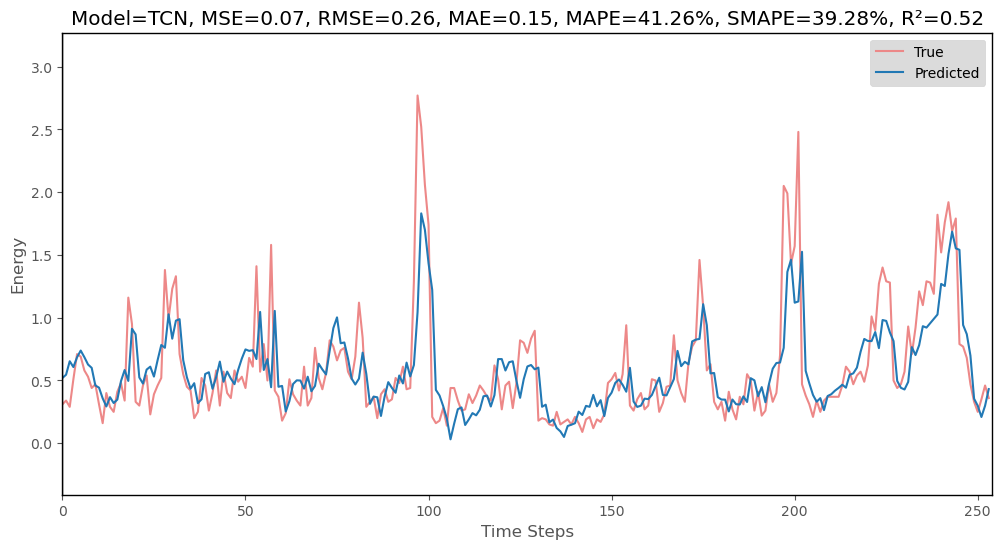

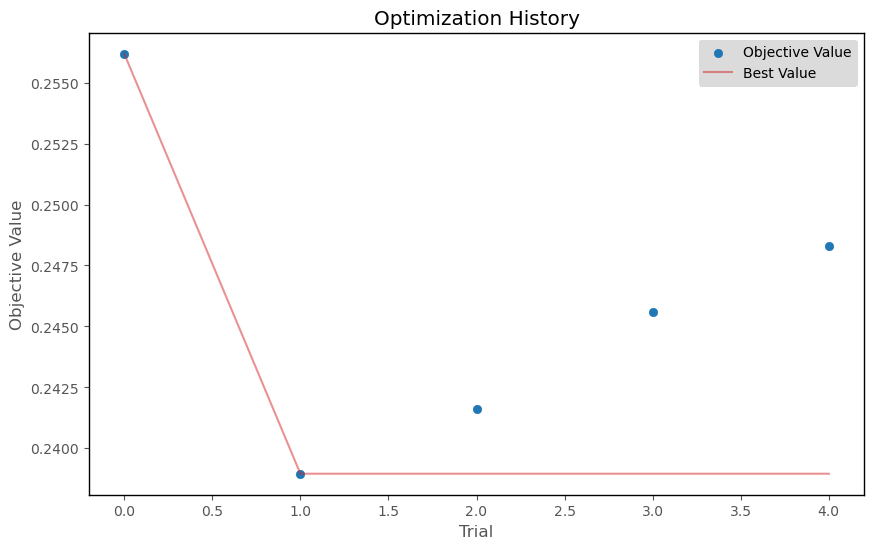

In [10]:
# model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']
model_types = ['TCN']

# Example usage
data = (X_train, y_train, X_val, y_val, X_test, y_test)

for model_type in model_types:
    best_model = functions.optimize_and_save_model(data, df_name, n_trials=5, epochs=100, verbosity=0, model_type=model_type)
    # best_rf = optimize_and_save_rf_model(data, df_name, n_trials=2, verbosity=1, model_type=model_type)

# Background Data

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import os
from matplotlib.backends.backend_pdf import PdfPages

def save_importance_plots(df_name, X_train, model_type='CNN'):
    # Create the subfolder in Models and Plots directories if it doesn't exist
    result_dir = "./Results"
    os.makedirs(result_dir, exist_ok=True)

    model_dir = f"./Results/Models/{df_name}"
    plot_dir = f"./Results/Plots/{df_name}"

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    # Load the saved Random Forest model
    model_path = f"./{model_dir}/{model_type}_RandomForest.pkl"
    best_rf = joblib.load(model_path)

    # Get the feature importances
    feature_importances = best_rf.feature_importances_

    # Reshape into a 48x10 dataframe
    importances_reshaped = feature_importances.reshape(X_train.shape[1], X_train.shape[2])
    importances_df = pd.DataFrame(importances_reshaped, columns=df.columns)

    # Open a PDF file to save the plots
    pdf_path = f"{plot_dir}/{model_type}_GlobalFeatures_RandomForest.pdf"
    with PdfPages(pdf_path) as pdf:
        # Plot 1: Heatmap with Annotations
        plt.figure(figsize=(10, 8))
        sns.heatmap(importances_df, cmap='coolwarm', annot=True, fmt=".4f")
        plt.title(f'Global Feature Importance of Sequence Windows for {model_type} Model - Heatmap')
        plt.xlabel('Features')
        plt.ylabel('Sequences')
        plt.tight_layout()  # Adjust layout to fit everything within the figure
        pdf.savefig()  # Save the current figure to the PDF
        plt.close()

        # Calculate normalized mean absolute values
        mean_absolute_values = importances_df.apply(lambda x: np.mean(np.abs(x)))
        normalized_values = mean_absolute_values / mean_absolute_values.sum()

        # Convert the normalized values to lists
        features = list(normalized_values.index)
        mean_abs_values = list(normalized_values.values)

        # Plot 2: Normalized Mean Absolute Value by Feature
        plt.figure(figsize=(16, 6))  # Further increase figure width to 16 units
        plt.barh(features, mean_abs_values, color='skyblue', edgecolor='black')
        plt.title(f'Normalized Mean Absolute Feature Importance for {model_type} Model - Bar Plot', fontsize=16)
        plt.xlabel('Normalized Mean Absolute Value', fontsize=14)
        plt.ylabel('Features', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)

        # Annotate the bars with the values, keeping the horizontal position unchanged
        for index, value in enumerate(mean_abs_values):
            plt.text(value, index, f'{value:.4f}', va='center', ha='left', fontsize=12)

        plt.tight_layout()  # Adjust layout to fit everything within the figure
        pdf.savefig()  # Save the current figure to the PDF
        plt.close()

    print(f"Plots have been saved to {pdf_path}")
    return normalized_values.values.flatten()

# Example usage:
normalized_values = save_importance_plots(df_name, X_train, model_type='CNN')


Plots have been saved to ./Results/Plots/house1.csv/CNN_GlobalFeatures_RandomForest.pdf


# Explaination

In [59]:
import numpy as np
import pandas as pd
import shap
import joblib
import os
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.models import load_model  # Assuming you are using TensorFlow/Keras

def analyze_model(df_name, X_train, new_data, features_name, model_type='CNN', general_method=0.01, horizon=0, similar_background=False, num_neighbors=100):
    # Step 1: Create directories for saving results
    result_dir = "./Results"
    os.makedirs(result_dir, exist_ok=True)

    model_dir = f"./Results/Models/{df_name}"
    os.makedirs(model_dir, exist_ok=True)

    # Step 2: Load the Random Forest model to obtain feature importances
    RandomForest_model_path = f"{model_dir}/{model_type}_RandomForest.pkl"
    RandomForest_model = joblib.load(RandomForest_model_path)
    feature_importances = RandomForest_model.feature_importances_
    importances_reshaped = feature_importances.reshape(X_train.shape[1], X_train.shape[2])
    importances_df = pd.DataFrame(importances_reshaped, columns=features_name)
    
    mean_absolute_values = importances_df.apply(lambda x: np.mean(np.abs(x)))
    normalized_values = mean_absolute_values / mean_absolute_values.sum()
    normalized_values_flattened = normalized_values.values.flatten()

    # Step 3: Select relevant background data if necessary
    if similar_background:
        # Flatten the test instance and training data
        test_instance_flattened = new_data.flatten().reshape(1, -1)
        X_train_flattened = X_train.reshape(X_train.shape[0], -1)

        # Apply weights to the flattened data
        test_instance_weighted = test_instance_flattened * normalized_values_flattened
        X_train_weighted = X_train_flattened * normalized_values_flattened

        # Compute weighted cosine similarity using NearestNeighbors
        knn = NearestNeighbors(n_neighbors=num_neighbors, metric='cosine')
        knn.fit(X_train_weighted)
        distances, indices = knn.kneighbors(test_instance_weighted)

        background_training = X_train[indices[0]]
    else:
        background_training = X_train[:int(X_train.shape[0] * general_method)]

    background_data = background_training.reshape(background_training.shape[0], -1)
    test_data = new_data.reshape(new_data.shape[0], -1)

    # Step 4: Load the main model for which SHAP values will be calculated
    best_model = load_model(f"{model_dir}/{model_type}.keras")

    # Step 5: Define the model prediction function
    def model_predict(data):
        reshaped_data = data.reshape((-1, new_data.shape[1], new_data.shape[2]))
        return best_model.predict(reshaped_data)

    # Step 6: Calculate SHAP values
    explainer = shap.KernelExplainer(model_predict, background_data)
    shap_values = explainer.shap_values(test_data)

    baseline_predictions = model_predict(background_data).mean(axis=0)
    shap_df = pd.DataFrame(shap_values[0, :, horizon].reshape(new_data.shape[1], new_data.shape[2]))

    result = {
        'explainer': explainer,
        'shap_values': shap_values,
        'shap_df': shap_df,
        'background_training': background_training,
        'baseline_predictions': baseline_predictions,
        'normalized_importance_values': normalized_values_flattened
    }

    return result

# Example usage:
result = analyze_model(df_name, X_train, new_data=X_test[:1], features_name=df.columns, model_type='CNN', general_method=0.01, horizon=0, similar_background=False, num_neighbors=100)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Using 203 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
19082/19082 ━━━━━━━━━━━━━━━━━━━━ 12s 639us/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [372]:
import numpy as np
import pandas as pd
import shap
from sklearn.neighbors import NearestNeighbors

import numpy as np
from sklearn.neighbors import NearestNeighbors


data = (X_train, y_train, X_val, y_val, X_test, y_test)



# Function to find the most relevant background data based on weighted cosine similarity
def select_relevant_background_data(X_train, test_instance, weights = normalized_values.values.flatten(), num_neighbors=10):
    # Flatten the test instance and training data
    test_instance_flattened = test_instance.flatten().reshape(1, -1)
    X_train_flattened = X_train.reshape(X_train.shape[0], -1)

    # Apply weights to the flattened data
    test_instance_weighted = test_instance_flattened * weights
    X_train_weighted = X_train_flattened * weights

    # Compute weighted cosine similarity using NearestNeighbors
    knn = NearestNeighbors(n_neighbors=num_neighbors, metric='cosine')
    knn.fit(X_train_weighted)
    distances, indices = knn.kneighbors(test_instance_weighted)

    return X_train[indices[0]]

# Function to calculate SHAP values
def my_shap(model, X_train, new_data, general_method=0.01, horizon=0, similar_background=False, num_neighbors=100):
    if similar_background:
        background_training = select_relevant_background_data(X_train, new_data, num_neighbors=num_neighbors)
    else:
        background_training = X_train[:int(X_train.shape[0] * general_method)]

    # Prepare background data (flattened for KernelExplainer)
    background_data = background_training.reshape(background_training.shape[0], -1)  # Flatten to 2D matrix
    test_data = new_data.reshape(new_data.shape[0], -1)  # Flatten to 2D matrix for explanation

    # Define a prediction function that reshapes the 2D input back to 3D
    def model_predict(data):
        reshaped_data = data.reshape((-1, new_data.shape[1], new_data.shape[2]))
        return model.predict(reshaped_data)

    # Initialize the SHAP KernelExplainer
    explainer = shap.KernelExplainer(model_predict, background_data)

    # Calculate SHAP values
    shap_values = explainer.shap_values(test_data)

    # Calculate the baseline predictions using the background data
    baseline_predictions = model_predict(background_data).mean(axis=0)

    # Create DataFrame for SHAP values
    shap_df = pd.DataFrame(shap_values[0,:,horizon].reshape(new_data.shape[1], new_data.shape[2]))

    result = {'explainer': explainer, 'shap_values': shap_values, 'shap_df': shap_df, 'background_training': background_training, 'baseline_predictions': baseline_predictions}
    return result


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
9400/9400 ━━━━━━━━━━━━━━━━━━━━ 103s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [374]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=True, num_neighbors=100)

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = df.columns

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

In [386]:
new_data = X_test[:1]
data = new_data[0,0,:]

background_data = pd.DataFrame(background_training[:,0,:].reshape(background_training[:,0,:].shape[0], background_training[:,0,:].shape[1]), columns=feature_names)
base_values = baseline_predictions[0] #first hirozon

values = np.array(shap_df.loc[0,:])

# Create a SHAP Explanation object
explanation = shap.Explanation(values=values, base_values=base_values, data=data, feature_names=feature_names)

# Visualize the SHAP values with a force plot including feature names
shap.initjs()
shap.force_plot(explanation.base_values, explanation.values, explanation.data, feature_names=explanation.feature_names)


In [388]:
time_id = 47
new_data = X_test[:1]
data = new_data[0,time_id,:]
data

background_data = pd.DataFrame(background_training[:,0,:].reshape(background_training[:,0,:].shape[0], background_training[:,0,:].shape[1]), columns=feature_names)

shap_values = np.array(shap_df.loc[time_id,:])

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values, base_values=base_values, data=data, feature_names=feature_names)

# Visualize the SHAP values with a force plot including feature names
shap.initjs()
shap.force_plot(explanation.base_values, explanation.values, explanation.data, feature_names=explanation.feature_names)


# similar method

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
94000/94000 ━━━━━━━━━━━━━━━━━━━━ 1032s 11ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


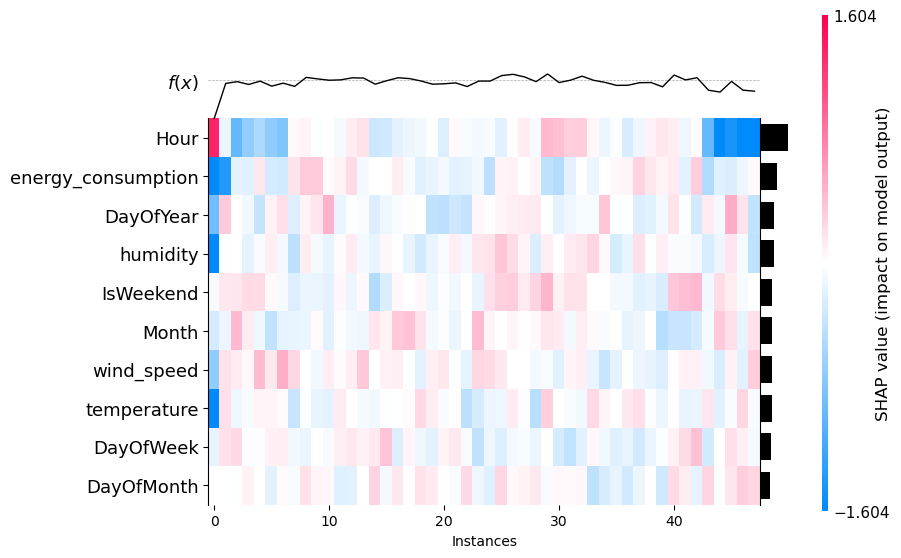

<Axes: xlabel='Instances'>

In [428]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.001, horizon = 0, similar_background=True, num_neighbors=1000)

feature_names = ["temperature", "humidity", "wind_speed", "energy_consumption", "Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend"]

new_data = X_test[:1]

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = feature_names

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

shap_values_new = np.array(shap_df)
shap_data_new = new_data[0,:,:]
# base_values_new = np.full((shap_data.shape[0],), abs(y_test[0][0][0] - base_values))  # 10 is the size of the array, 5 is the repeated value
base_values_new = np.full((shap_data.shape[0],), baseline_predictions[0]) #first hirozon)  # 10 is the size of the array, 5 is the repeated value

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values_new, base_values=base_values_new, data=shap_data_new, feature_names=feature_names)

# Visualize the SHAP values with a force plot including feature names
shap.plots.heatmap(explanation)


# general method

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6383/6383 ━━━━━━━━━━━━━━━━━━━━ 70s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


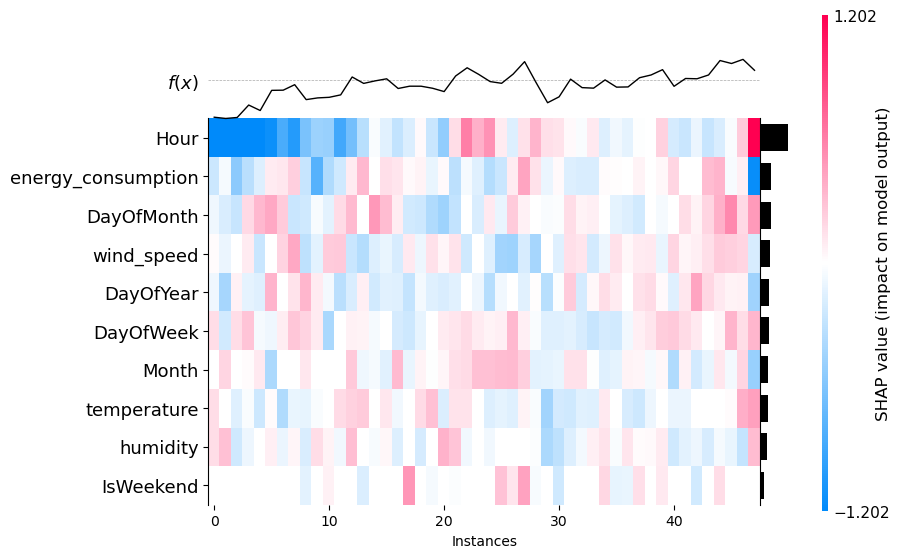

<Axes: xlabel='Instances'>

In [407]:
result = my_shap(best_model, background_training = X_train, new_data = X_test[:1], general_method = 0.01, horizon = 0, similar_background=False, num_neighbors=100)

feature_names = ["temperature", "humidity", "wind_speed", "energy_consumption", "Hour", "DayOfWeek", "DayOfMonth", "Month", "DayOfYear", "IsWeekend"]

new_data = X_test[:1]

# Visualizing the SHAP values
shap_df = result['shap_df']
shap_df.columns = feature_names

shap_values = result['shap_values']
explainer = result['explainer']
background_training = result['background_training']
baseline_predictions = result['baseline_predictions']

shap_values_new = np.array(shap_df)
shap_data_new = new_data[0,:,:]
# base_values_new = np.full((shap_data.shape[0],), abs(y_test[0][0][0] - base_values))  # 10 is the size of the array, 5 is the repeated value
base_values_new = np.full((shap_data.shape[0],), baseline_predictions[0]) #first hirozon)  # 10 is the size of the array, 5 is the repeated value

# Create a SHAP Explanation object
explanation = shap.Explanation(values=shap_values_new, base_values=base_values_new, data=shap_data_new, feature_names=feature_names)

# Visualize the SHAP values with a force plot including feature names
shap.plots.heatmap(explanation)


In [426]:
import pandas as pd
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score

# Assuming X_train is your input data and you want to work with it
time_series_data = pd.DataFrame(X_train[:,0,:]).values  # Convert DataFrame to numpy array if not already

# Normalize time series data
scaler = TimeSeriesScalerMeanVariance(mu=0., std=1.)
time_series_data_scaled = scaler.fit_transform(time_series_data)

# Flatten the time series data to 2D for silhouette score calculation
time_series_data_flattened = time_series_data_scaled.reshape(time_series_data_scaled.shape[0], -1)

# Define a range of clusters to evaluate
range_n_clusters = list(range(2, 10))

# Iterate over the range to find the best number of clusters
best_n_clusters = None
best_score = -1

for n_clusters in range_n_clusters:
    model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", verbose=False, random_state=0)
    cluster_labels = model.fit_predict(time_series_data_scaled)
    
    # Compute silhouette score
    silhouette_avg = silhouette_score(time_series_data_flattened, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")
    
    if silhouette_avg > best_score:
        best_score = silhouette_avg
        best_n_clusters = n_clusters

print(f"The best number of clusters is: {best_n_clusters} with a silhouette score of {best_score}")


For n_clusters = 2, the average silhouette_score is : 0.5788879274589342
For n_clusters = 3, the average silhouette_score is : 0.4636405261996103
For n_clusters = 4, the average silhouette_score is : 0.4125472276472811
For n_clusters = 5, the average silhouette_score is : 0.37911868962056017
For n_clusters = 6, the average silhouette_score is : 0.3423962215157725
For n_clusters = 7, the average silhouette_score is : 0.3020150734941496
For n_clusters = 8, the average silhouette_score is : 0.29432299969785863
For n_clusters = 9, the average silhouette_score is : 0.2772532157901801
The best number of clusters is: 2 with a silhouette score of 0.5788879274589342
